# Univariate Exploratory Data Analysis

In this notebook I will perform univariate analysis

## Setup

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))
from src import get_stats, get_outliers, get_nans

data = pd.read_parquet("../data/bronze/clean_dataset.parquet",  engine='pyarrow')
data = data.sort_values(["date", "time"]).reset_index(drop=True)



In [2]:
print(f"Dataset shape: {data.shape}")
print(f"Cancellation rate: {data['is_cancelled'].mean():.2%}")


Dataset shape: (150000, 13)
Cancellation rate: 32.00%


In [3]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [4]:
data.tail()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
149995,2024-12-30,22:58:00,CNR9030698,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.799999,440.0,12.850000,UPI,0.0
149996,2024-12-30,23:03:14,CNR1507833,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.599998,279.0,39.360001,UPI,0.0
149997,2024-12-30,23:17:05,CNR2265113,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.900002,1855.0,38.910000,UPI,0.0
149998,2024-12-30,23:21:12,CNR4066733,CID8938559,Uber XL,Ashram,Vasant Kunj,2.6,26.700001,520.0,36.369999,Uber Wallet,0.0
149999,2024-12-30,23:36:11,CNR6915581,CID5185745,Auto,Pitampura,Nehru Place,3.5,11.900000,571.0,2.670000,UPI,0.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   date             150000 non-null  object  
 1   time             150000 non-null  object  
 2   booking_id       150000 non-null  string  
 3   customer_id      150000 non-null  string  
 4   vehicle_type     150000 non-null  category
 5   pickup_location  150000 non-null  category
 6   drop_location    150000 non-null  category
 7   avg_vtat         139500 non-null  float32 
 8   avg_ctat         102000 non-null  float32 
 9   booking_value    102000 non-null  float32 
 10  ride_distance    102000 non-null  float32 
 11  payment_method   102000 non-null  category
 12  is_cancelled     150000 non-null  float32 
dtypes: category(4), float32(5), object(2), string(2)
memory usage: 8.3+ MB


In [6]:
get_stats(data)

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
count,150000,150000,150000,150000,150000,150000,150000,139500.0,102000.0,102000.0,102000.0,102000,150000.0
unique,365,62910,148767,148788,7,176,176,NaN,NaN,NaN,NaN,5,NaN
top,2024-11-16,17:44:57,CNR2726142,CID5481002,Auto,Khandsa,Ashram,NaN,NaN,NaN,NaN,UPI,NaN
freq,462,16,3,3,37419,949,936,NaN,NaN,NaN,NaN,45909,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456351,29.149632,508.295929,24.637012,NaN,0.32
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,395.805756,14.002138,NaN,0.466478
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,50.0,1.0,NaN,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,21.6,234.0,12.46,NaN,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.3,28.799999,414.0,23.719999,NaN,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.3,36.799999,689.0,36.82,NaN,1.0


150000 samples with 12 columns. We have date and time so the data is ordered and a is_cancelled label already binarized.

Observations:
- Null values: avg_vtat, avg_ctat, booking_value, ride_distance, payment_method
- Range of all features make sense based on their meaning. Just to make sure the max booking_value 4277.0 it quite high. Let's observe them later.
- Most means and standard deviations make sense to me but again I will just check the booking_value because of its high values 
- Unique values make sense to me too. Only booking_id and customer_id as the feature says are IDs so they can have high cardinality. 



## Univariate Analysis


Are there potential duplicate bookings where the same customer, time, and location appear more than once?


In [7]:
potential_dup_cols = ['customer_id', 'date', 'time', 'pickup_location', 'drop_location']

if all(col in data.columns for col in potential_dup_cols):
    potential_dups = data.duplicated(subset=potential_dup_cols).sum()
    print(f"\nPotential duplicate bookings: {potential_dups:,}")



Potential duplicate bookings: 0


### date


How are the top 20 most frequent dates distributed, and do any anomalies or patterns stand out?


In [8]:
date_counts = data['date'].value_counts()
date_counts.head(20)

date
2024-11-16    462
2024-09-18    456
2024-05-09    456
2024-02-06    452
2024-10-12    452
2024-01-26    452
2024-10-13    451
2024-10-09    451
2024-07-17    451
2024-11-29    450
2024-04-01    449
2024-02-16    449
2024-01-21    449
2024-03-12    448
2024-07-05    446
2024-03-18    446
2024-04-26    446
2024-02-04    446
2024-12-22    446
2024-05-14    445
Name: count, dtype: int64

There is no clear pattern here. Almost every month has a day with a really high amount of bookings

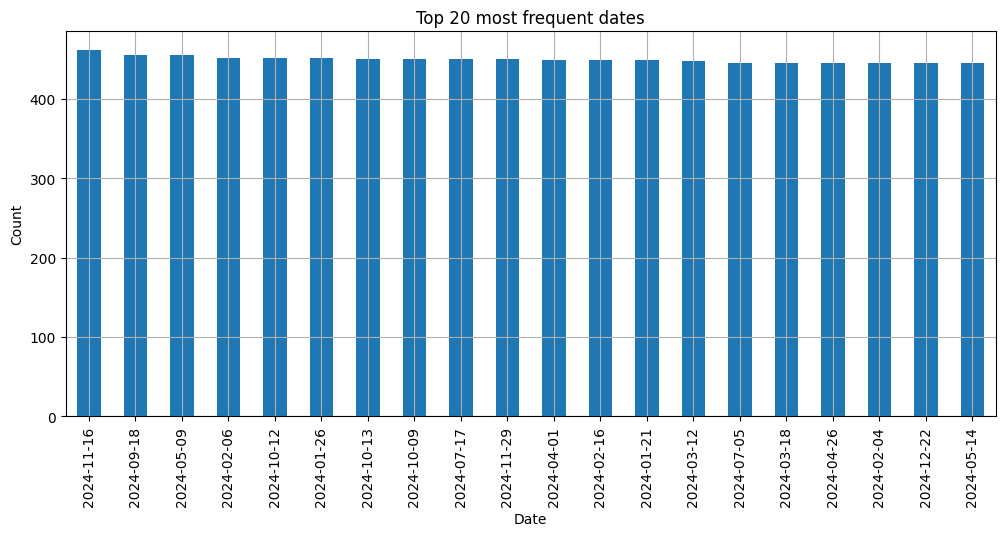

In [9]:
plt.figure(figsize=(12,5))
date_counts.head(20).plot(kind='bar')
plt.title("Top 20 most frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


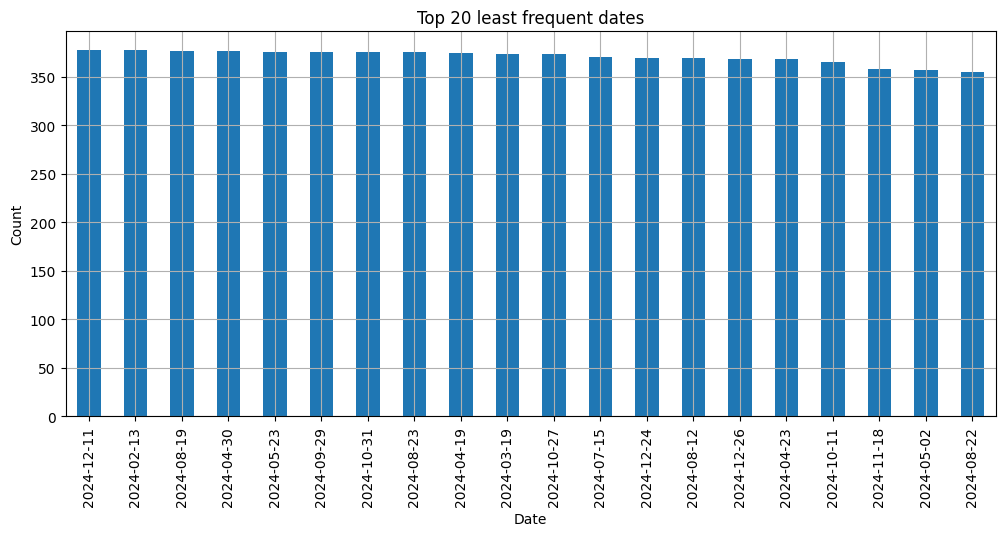

In [10]:
plt.figure(figsize=(12,5))
date_counts.tail(20).plot(kind='bar')
plt.title("Top 20 least frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


The spread across the top 20 days is only 17 bookings, which is quite narrow. Why does it cap at that level? Is it a coincidence, some kind of capacity bottleneck, or simply the natural demand ceiling for this city?

Each day of the year has roughly between 350 and 460 records.

It would be worth checking whether these high-traffic days correspond to holidays or special events, and whether the relationship with cancellations suggests this is genuine peak demand or a flattening effect caused by service limitations.

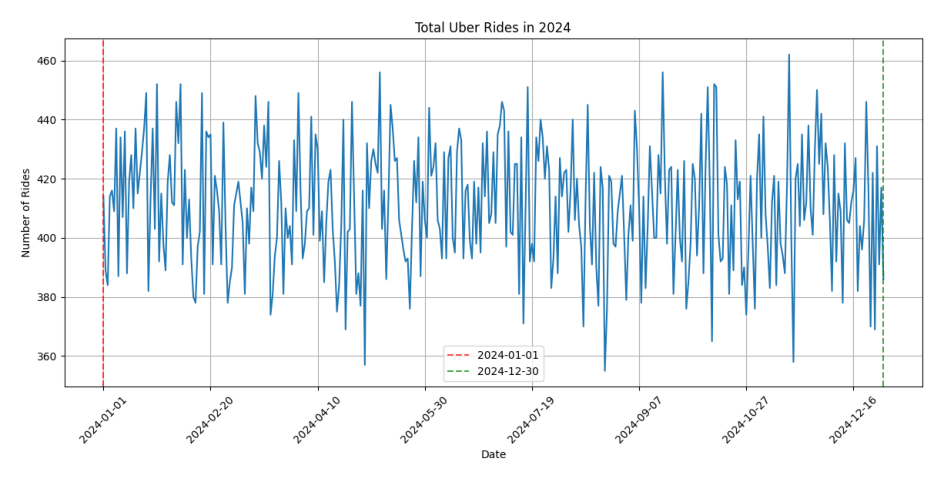

In [11]:

# Given the computational constrains of my laptop and the size of some plots, I store them in images/  

plot_file = 'imgs/date_lineplot.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    daily_counts = data.groupby('date').size()
    plt.plot(daily_counts.index, daily_counts.values)

    first_date = daily_counts.index.min()
    last_date = daily_counts.index.max()
    first_date_label = daily_counts.index.min()
    last_date_label = daily_counts.index.max()
    plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
    plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
    plt.title('Total Uber Rides in 2024')
    plt.xlabel('Date')
    plt.ylabel('Number of Rides')

    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.grid()
    plt.legend()
    plt.tight_layout()
    os.makedirs('imgs', exist_ok=True) 
    plt.savefig(plot_file)
    plt.show()



How can there be 365 unique date values if December 31st is missing? Could this be a leap year with a February 29th entry?

In [12]:
data[data["date"] == "2024-02-29"].head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
24403,2024-02-29,00:00:09,CNR2330207,CID8309113,Auto,Kirti Nagar,Sonipat,9.3,NaN,NaN,NaN,NaN,1.0
24404,2024-02-29,00:08:57,CNR6004216,CID5184316,Go Mini,Meerut,Ghitorni Village,2.8,21.799999,621.0,6.470000,Credit Card,0.0
24405,2024-02-29,00:24:06,CNR1464111,CID1168333,Premier Sedan,Malviya Nagar,Udyog Vihar,3.2,20.200001,444.0,28.160000,Cash,0.0
24406,2024-02-29,00:36:19,CNR3852671,CID4695190,Premier Sedan,Malviya Nagar,Connaught Place,NaN,NaN,NaN,NaN,NaN,1.0
24407,2024-02-29,01:10:18,CNR9446862,CID3841042,Bike,Okhla,Sarojini Nagar,3.7,25.400000,362.0,37.630001,Credit Card,0.0


Confirmed, it's a leap year, that accounts for the 365 unique dates. We need talk with the team and try to find data from the 31st of Dec



### time

How are the top 20 most frequent times distributed, and do any anomalies or patterns stand out?

In [13]:
time = data['time'].value_counts()
time.head(20)

time
17:44:57    16
19:17:33    12
17:54:33    11
18:59:55    11
17:55:08    11
11:29:50    11
19:26:48    11
10:23:23    11
15:23:56    11
19:29:07    10
17:38:15    10
18:07:46    10
18:09:57    10
17:34:15    10
18:17:18    10
20:46:08    10
16:16:59    10
19:44:48    10
18:10:37    10
09:45:20    10
Name: count, dtype: int64

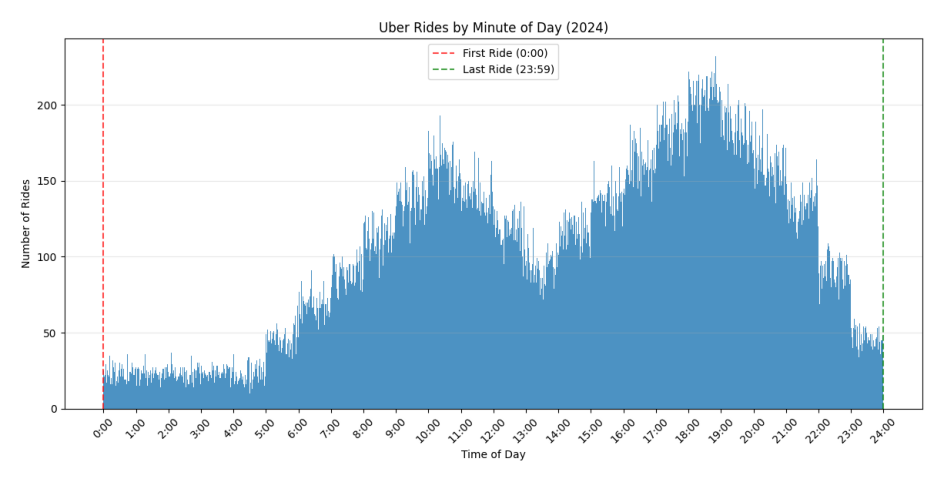

In [14]:
plot_file = 'imgs/time_hist_minute.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    time_parsed = pd.to_datetime(data['time'], format='%H:%M:%S')
    minutes = time_parsed.dt.hour * 60 + time_parsed.dt.minute

    first_min = int(minutes.min())
    last_min = int(minutes.max())

    plt.figure(figsize=(12, 6))
    plt.hist(minutes, bins=range(0, 1441, 1), edgecolor='none', alpha=0.8)

    plt.axvline(first_min, color='red', linestyle='--', alpha=0.7, label=f'First Ride ({first_min // 60}:{first_min % 60:02d})')
    plt.axvline(last_min, color='green', linestyle='--', alpha=0.7, label=f'Last Ride ({last_min // 60}:{last_min % 60:02d})')

    hour_ticks = list(range(0, 1441, 60))
    hour_labels = [f'{h}:00' for h in range(25)]
    plt.xticks(hour_ticks, hour_labels, rotation=45)

    plt.title('Uber Rides by Minute of Day (2024)')
    plt.xlabel('Time of Day')
    plt.ylabel('Number of Rides')
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True)
    plt.savefig(plot_file)
    plt.show()


The minute-level histogram above uses too many bins, which creates a spiky appearance where random minute-to-minute fluctuations look like meaningful patterns. I will leave here for demo reasons and add aggregation to hourly granularity to smooth out this noise and reveal the true demand shape!

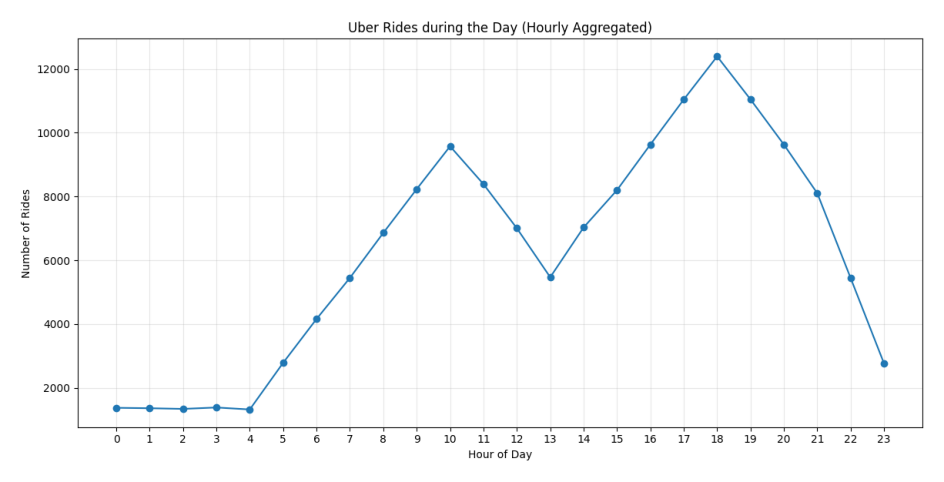

In [15]:
plot_file = 'imgs/time_lineplot_hour.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    time_parsed = pd.to_datetime(data['time'], format='%H:%M:%S')
    time_counts = (
        data
        .assign(hour=time_parsed.dt.hour)
        .groupby('hour')
        .size()
        .sort_index()
    )

    plt.plot(time_counts.index, time_counts.values)

    first_hour = time_counts.index.min()
    last_hour = time_counts.index.max()
    plt.axvline(first_hour, color='red', linestyle='--', alpha=0.7, label=f'First Hour ({first_hour}:00)')
    plt.axvline(last_hour, color='green', linestyle='--', alpha=0.7, label=f'Last Hour ({last_hour}:00)')

    plt.title('Uber Rides during the Day (Hourly)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Rides')

    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True)
    plt.savefig(plot_file)
    plt.show()


Cool! Now we can see something. Activity is minimal during the early morning hours, rises sharply during the morning commute with a peak around 10 AM, dips around midday, and reaches its highest level in the early evening (around 6 PM). Demand then steadily declines toward the end of the day. 

This pattern could be a useful signal for feature engineering. Later in the bivariate_eda notebook I will extract temporal components that could be useful like month, day_of_week, hour, quarter, etc.

### booking_id


In [21]:
# format check
data_booking = data.copy()
data_booking['booking_length'] = data_booking['booking_id'].str.len()
print(f"Unique lengths of booking_id strings: {data_booking['booking_length'].nunique()}")
print(f"Total booking_ids: {data_booking['booking_length'].value_counts().sum()}")
print(f"Example booking_id: {data_booking['booking_id'].iloc[0]}")


Unique lengths of booking_id strings: 1
Total booking_ids: 150000
Example booking_id: CNR4352144


what is the letter code in front of the number? how many do we have? 


In [22]:
import re

data_booking[["letters_b", "numbers_b"]] = data_booking["booking_id"].str.extract(r"([A-Za-z]+)([0-9]+)")

count_letters_b = data_booking["letters_b"].value_counts(dropna = False)
count_numbers_b = data_booking["numbers_b"].value_counts(dropna = False)

# are the values in front of the numbers valuable?
count_letters_b
# count_numbers_b

letters_b
CNR    150000
Name: count, dtype: Int64

All rows share the same letter code "CNR", the number is the unique identifier

what is the range of the numbers?
how many duplicated booking IDs there are and how many times? why?

In [23]:
count_numbers = count_numbers_b.astype("int32").sort_index()
print(f" The min value is: {count_numbers_b.idxmin()}, the max value is: {count_numbers_b.idxmax()}")


 The min value is: 1405409, the max value is: 2726142


I will leave for a further analysis if there is a continuity in the sequence of those numbers

In [24]:

# pd.set_option("display.max_columns", None)
multiple_bookings = data[data["booking_id"].duplicated(keep=False)]
print(f" There are {len(multiple_bookings)} duplicated from which:")


counts_bookings = data["booking_id"].value_counts()
ids_duplicated_twice = counts_bookings[counts_bookings == 2].index
duplicates_twice = data[data["booking_id"].isin(ids_duplicated_twice)].sort_values(["booking_id"])
print(f" There are {len(duplicates_twice)} rows with the same booking_id appearing two times")

ids_duplicated_thrice = counts_bookings[counts_bookings == 3].index
duplicates_thrice = data[data["booking_id"].isin(ids_duplicated_thrice)].sort_values(["booking_id", "date", "time"])
print(f" There are {len(duplicates_thrice)} rows with the same booking_id appearing three times")


 There are 2457 duplicated from which:
 There are 2430 rows with the same booking_id appearing two times
 There are 27 rows with the same booking_id appearing three times


Uber is reusing booking IDs in different ways:

1. For example "CNR1026036" was cancelled and then reused 3 months later
2. Another case is "CNR1029172", which appears twice for clearly different rides

Both cases represent ID misuse — these are duplicated IDs assigned to distinct rides. This is worth flagging as a data quality issue.

Looking at the rows that appear 3 times, they are completely different from one another. The dataset documentation describes this column as a unique identifier, so there is clearly a data quality problem here so the logic behind the generation and use of booking_id values should be investigated

Does each row increment by 1 compared to the previous row?

My guess to prove is that booking IDs are scoped per vehicle type, with each vehicle service generating its own ID sequence independently




### customer_id

In [25]:
# format check
data_customer = data.copy()
data_customer['customer_length'] = data_customer['customer_id'].str.len()
print(f"Unique lengths of time strings: {data_customer['customer_length'].nunique()}")
print(f"Total customer_id: {data_customer['customer_length'].value_counts().sum()}")
print(f"Example customer_id: {data_customer['customer_id'].iloc[0]}")
# there are no errors on the customer_id formats

Unique lengths of time strings: 1
Total customer_id: 150000
Example customer_id: CID8362794


In [26]:

data_customer[["letters_c", "numbers_c"]] = data_customer["customer_id"].str.extract(
    r"([A-Za-z]+)([0-9]+)"
)

count_letters_c = data_customer["letters_c"].value_counts(dropna = False)
count_numbers_c = data_customer["numbers_c"].value_counts(dropna = False)

# are the values in front of the numbers valuable?
count_letters_c
# count_numbers_c

letters_c
CID    150000
Name: count, dtype: Int64

All rows share the same letter code "CID"

what is the range of the numbers?
how many duplicated customer IDs there are and how many times? why?

In [27]:
# what is the range of the numbers?

count_numbers_c = count_numbers_c.astype("int32").sort_index()
print(f" The min value is: {count_numbers_c.idxmin()}, the max value is: {count_numbers_c.idxmax()}")


 The min value is: 1000119, the max value is: 4523979


In [28]:
# how many duplicated booking IDs and how many times? why?

# pd.set_option("display.max_columns", None)
duplicates = data[data["customer_id"].duplicated(keep=False)]
print(f" There are {len(duplicates)} duplicated customer IDs from which:")


counts_customers = data["customer_id"].value_counts()
ids_duplicated_twice = counts_customers[counts_customers == 2].index
duplicated_customers = data[data["customer_id"].isin(ids_duplicated_twice)].sort_values(["customer_id", "date", "time"])
print(f" There are {len(duplicated_customers)} rows appearing two times")


ids_duplicated_thrice = counts_customers[counts_customers == 3].index
triplicated_customers = data[data["customer_id"].isin(ids_duplicated_thrice)].sort_values(["customer_id", "date", "time"])
print(f" There are {len(triplicated_customers)} rows appearing three times")

 There are 2418 duplicated customer IDs from which:
 There are 2400 rows appearing two times
 There are 18 rows appearing three times


The meaning and high cardinality of both booking_id and customer_id makes these columns useless so I will drop them


In [29]:

data.drop(columns=["booking_id", "customer_id"], inplace=True)

### vehicle_type

what is the distribution? how many types do we have? are all of them valid? 

In [30]:
vehicle_counts = data["vehicle_type"].value_counts(dropna = False)
vehicle_counts

vehicle_type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [31]:
vehicle_counts.index.to_list()

['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL']

<Axes: xlabel='vehicle_type'>

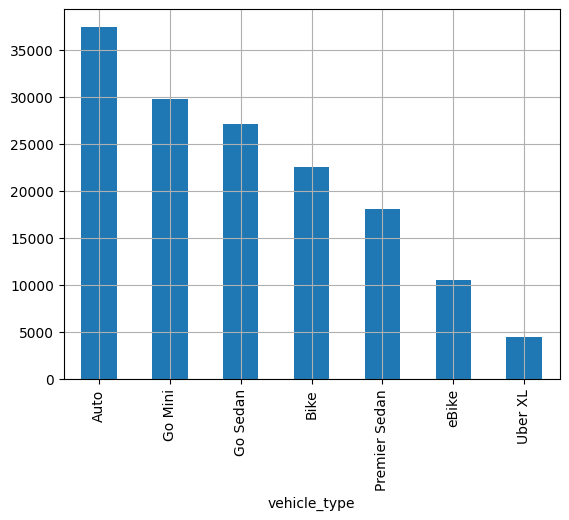

In [32]:
vehicle_counts.plot(kind = "bar", grid = True)

### pickup_location

how is the distribution of the pickup locations? are they all valid?  

In [33]:
# pd.set_option("display.max_rows", None)

pickups = data["pickup_location"].value_counts(dropna = False)
pickups

pickup_location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, Length: 176, dtype: int64

I don't have enough domain knowledge to verify whether all pickup locations are properly formatted, but this should be validated at some point

A total of 176 unique pickup locations were identified.
Pickup location counts range from 790 to 949.


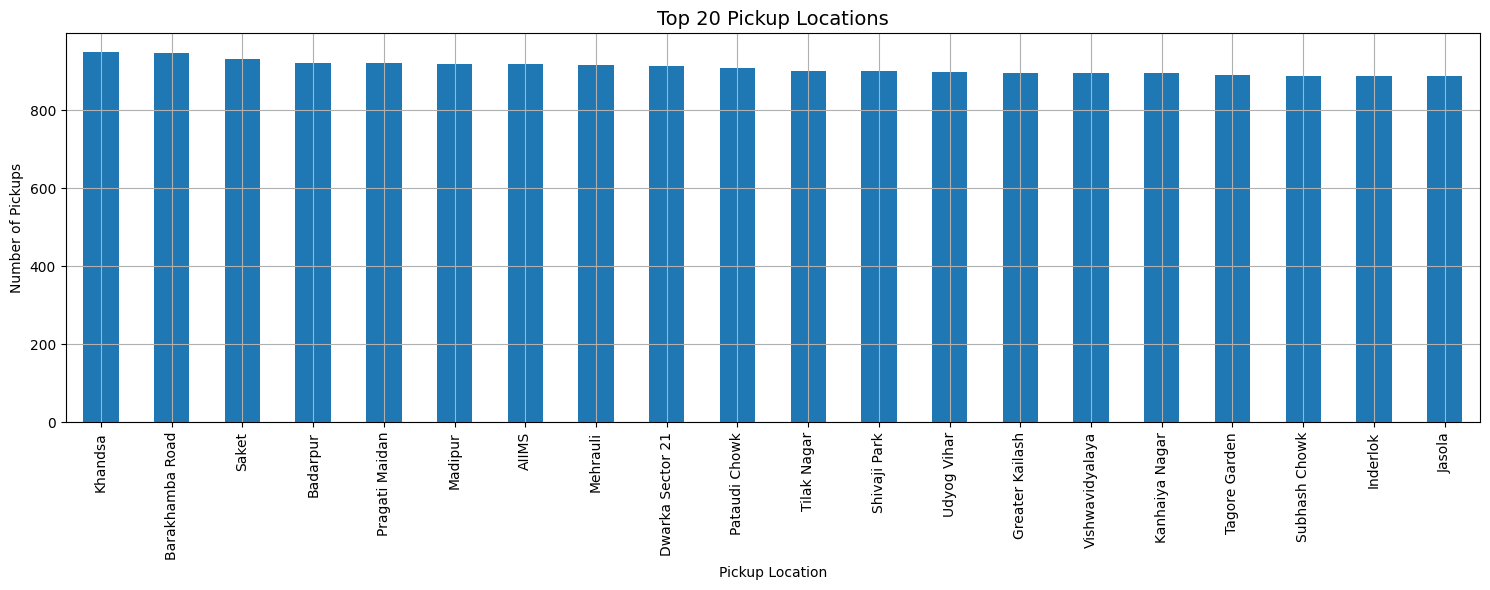

In [34]:
print(f"A total of {len(pickups)} unique pickup locations were identified.")
print(f"Pickup location counts range from {pickups.min()} to {pickups.max()}.")

ax = pickups.head(20).plot(
    kind="bar",
    figsize=(15,6),
    grid=True
)

ax.set_title("Top 20 Pickup Locations", fontsize=14)
ax.set_xlabel("Pickup Location")
ax.set_ylabel("Number of Pickups")

plt.tight_layout()
plt.show()

### drop location

how is the distribution of the drop locations? are they all valid?  

In [35]:
drops = data["drop_location"].value_counts(dropna = False)
drops

drop_location
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Cyber Hub           912
                   ... 
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, Length: 176, dtype: int64

Same situation as pickup locations, it would be worth verifying that all entries are real, properly formatted, and free of errors

A total of 176 unique drop locations were identified.
Drop counts range from 774 to 936.


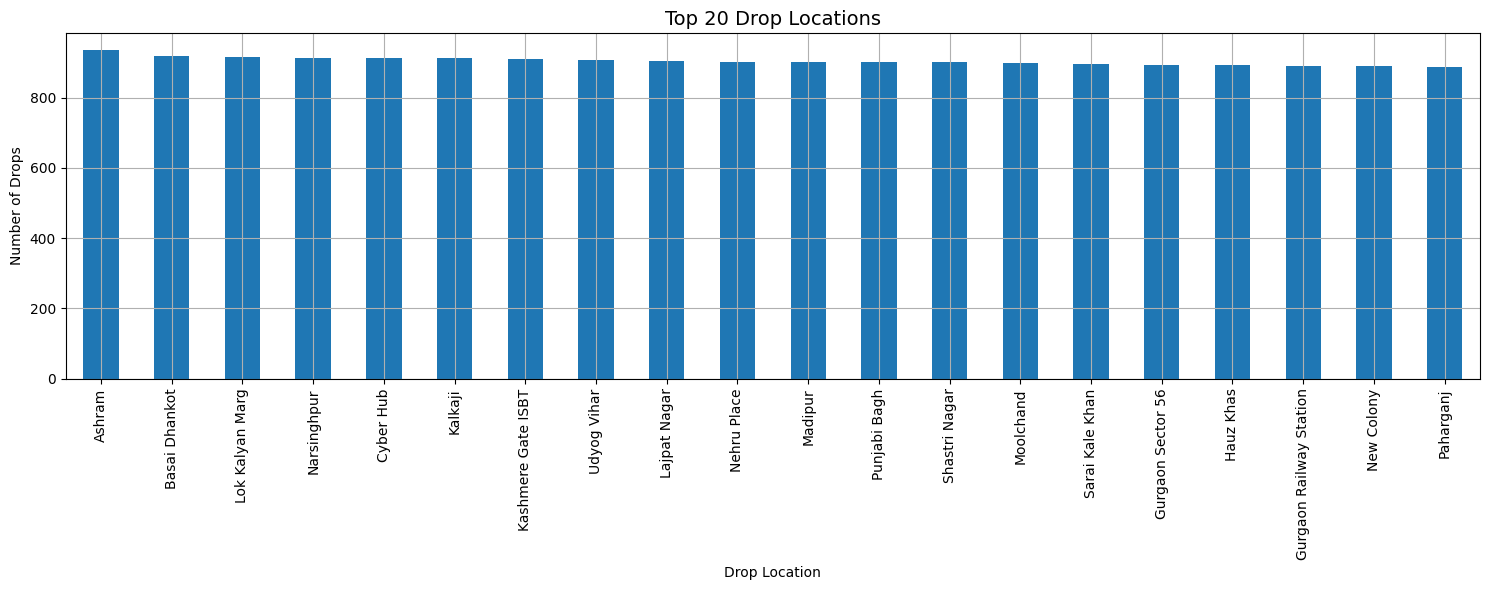

In [36]:
print(f"A total of {len(drops)} unique drop locations were identified.")
print(f"Drop counts range from {drops.min()} to {drops.max()}.")

ax = drops.head(20).plot(kind = "bar", figsize=(15,6), grid = True, title = "Top 20 Drop Locations")

ax.set_title("Top 20 Drop Locations", fontsize=14)
ax.set_xlabel("Drop Location")
ax.set_ylabel("Number of Drops")

plt.tight_layout()
plt.show()


### avg_vtat


At the begining of this notebook I found that there are 10500 nulls, a 7% of cells, what they mean and what's is the best strategy to manage them.

In [37]:
get_nans(data, "avg_vtat")

All cancelled rows match NaNs in is_cancelled? False
Number of cancelled rows: 48000
Number of NaN avg_ctat rows: 10500
Number of rows where both are True: 10500


Null values are not only linked to cancelled rides. They may occur because the driver arrival time wasn’t recorded or the pickup event didn’t log correctly. There could also be other hidden relationships. I’ll check multicollinearity later.

To handle the missing values, possible options:
- Median imputation 
- Group-based imputation
- Add a binary flag avg_vtat_missing
- Create avg_vtat_bins (ordinal feature with bins: 5, 10, 15, 20).

Do we have outliers?

In [38]:
get_outliers(data, "avg_vtat")


 avg_vtat: no outliers detected


From the stats analysis at the begining of the notebook, the distribution of avg_vtat is slightly right-skewed (skewness ~0.3) with a kurtosis of about -0.59, which means it's platykurtic. The mild right skew makes sense because a few drivers might take a bit longer to reach the pickup, but there's a natural ceiling on how far away the nearest driver can be

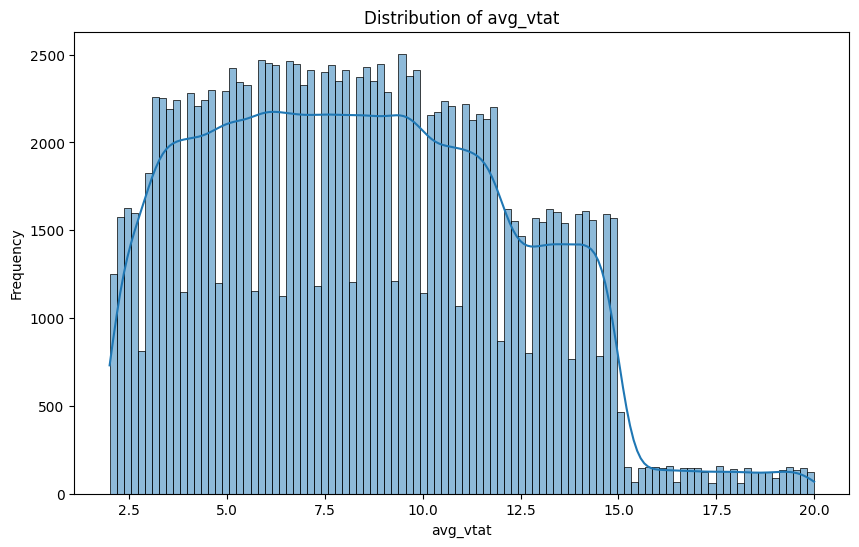

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(data["avg_vtat"], bins=100, kde=True)
plt.title("Distribution of avg_vtat")
plt.xlabel("avg_vtat")
plt.ylabel("Frequency")
plt.show()


The distribution is unimodal and slightly right-skewed with potential outliers. Most observations are concentrated in the range of 2-15 minutes. It would be interesting to create bins based on typical range divisions. 

Let's create the new features:

In [40]:
data["avg_vtat_missing"] = data["avg_vtat"].notna().astype(int)

bins = [0, 5, 10, 15, 20]
labels = ["0-5", "5–10", "10–15", "15–20"]

data["avg_vtat_bins"] = pd.cut( data["avg_vtat"], bins=bins,labels=labels)

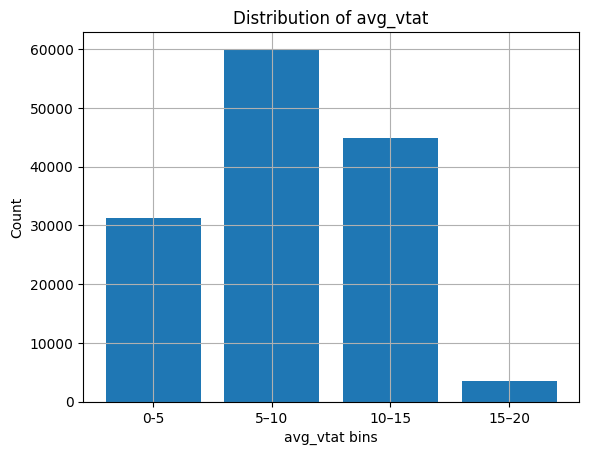

In [41]:
counts = data["avg_vtat_bins"].value_counts().sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("avg_vtat bins")
plt.ylabel("Count")
plt.title("Distribution of avg_vtat")
plt.grid()
plt.show()



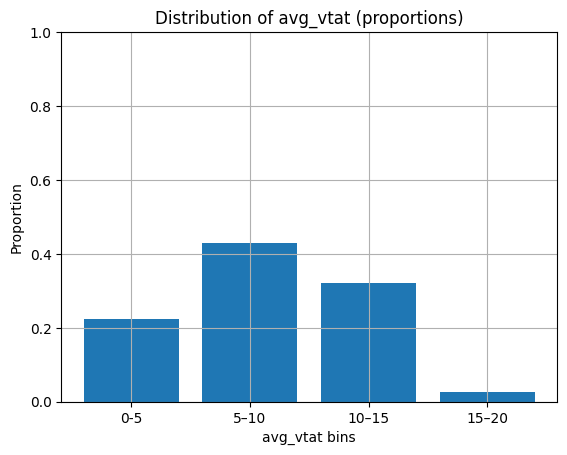

In [42]:
proportions = (
    data["avg_vtat_bins"]
    .value_counts(normalize=True)
    .sort_index()
)

plt.figure()
plt.bar(proportions.index.astype(str), proportions.values)
plt.xlabel("avg_vtat bins")
plt.ylabel("Proportion")
plt.title("Distribution of avg_vtat (proportions)")
plt.ylim(0, 1)
plt.grid()
plt.show()

In [43]:
data["avg_vtat_bins"].value_counts(normalize=True)

avg_vtat_bins
5–10     0.429362
10–15    0.320946
0-5      0.224452
15–20    0.025240
Name: proportion, dtype: float64

Interesting finding. While keeping in mind that I don't have enough context to fully understand the traffic dynamics in this city, it's striking that nearly a third of all rides involve a vehicle arrival time of up to 15 minutes. In my opinion, that could be a contributing factor to cancellations.

I'll analyze both the 5-10 and 10-15 minute bins in the bivariate analysis to look for patterns

### avg_ctat

Let's check Nans and outliers

In [44]:
get_nans(data, "avg_ctat")

All cancelled rows match NaNs in is_cancelled? True
Number of cancelled rows: 48000
Number of NaN avg_ctat rows: 48000
Number of rows where both are True: 48000


Oh, that's interesting. avg_ctat NaNs are not missing at random, they are missing because the ride was cancelled. Including them in a cancellation prediction would produce data leakage. This variable will be discarded.

In [45]:
data = data.drop(columns = ["avg_ctat"])

### booking value

Total fare amount for the ride in dollars

In [46]:
get_nans(data, "booking_value")

All cancelled rows match NaNs in is_cancelled? True
Number of cancelled rows: 48000
Number of NaN avg_ctat rows: 48000
Number of rows where both are True: 48000


### ride_distance

In [47]:
get_nans(data, "ride_distance")

All cancelled rows match NaNs in is_cancelled? True
Number of cancelled rows: 48000
Number of NaN avg_ctat rows: 48000
Number of rows where both are True: 48000


### payment method

Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)

In [48]:
get_nans(data, "payment_method")

All cancelled rows match NaNs in is_cancelled? True
Number of cancelled rows: 48000
Number of NaN avg_ctat rows: 48000
Number of rows where both are True: 48000


Wow, so "booking_value", "ride_distance" and "payment_method" are also NaN because the ride was cancelled so they also have to be dropped. 

In [49]:
data = data.drop(columns = ["booking_value", "ride_distance", "payment_method"])

## is_cancelled 

is_cancelled
0.0    0.68
1.0    0.32
Name: proportion, dtype: float64


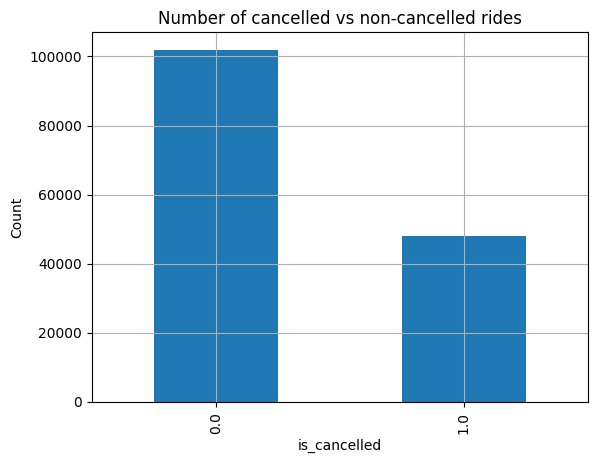

In [50]:
print(data["is_cancelled"].value_counts(normalize=True))

data["is_cancelled"].value_counts().plot(kind="bar")
plt.xlabel("is_cancelled")
plt.ylabel("Count")
plt.title("Number of cancelled vs non-cancelled rides")
plt.grid()
plt.show()


I have to address the class imbalance using class imbalance and tune the threshold. 

I drop date and time columns since they are already encoded in other variables. Date is inside datetime and time is inside hour and we don't care about a minute or second-wise analysis in this problem

In [51]:
# data.drop(columns=["date", "time"], inplace=True)

## Save dataset

In [52]:
data.to_parquet("../data/silver/data_to_bivar.parquet", engine='pyarrow')